## **Actividad: DASHboards y Plotly**

Alina A. Reyes Muñiz | A01752345

Montserrat Hernández Pérez | A01276367

In [1]:
import pandas as pd
import missingno as msno

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import plotly

import plotly.express as px # graficas principales
import plotly.figure_factory as ff # generar tipos especificos de figuras
import plotly.graph_objects as go # manipular elementos individuales
import pandas as pd

plotly.__version__

!pip install plotly

##**Dataset**

El dataset con el que se va a trabajar es *'sleep_deprivation_dataset_detailed.csv'*, el cuál tiene datos que explora los efectos de la privación del sueño en el rendimiento cognitivo y la regulación emocional, basándose en un estudio realizado en Oriente Medio en 2024.

Incluye a 60 participantes de diversos orígenes, tanto hombres (37), como mujeres (23), recopilando datos sobre la duración y la calidad del sueño, la somnolencia diurna, la función cognitiva (tiempos de reacción, precisión de la memoria) y la estabilidad emocional. Además, registra factores demográficos como la edad, el sexo, el IMC y las influencias del estilo de vida, como el consumo de cafeína, los niveles de actividad física y los niveles de estrés.


Fuente:
Tecnología de Sacramento. (2026). *Privación del sueño y rendimiento cognitivo*. Kaggle. https://www.kaggle.com/datasets/sacramentotechnology/sleep-deprivation-and-cognitive-performance

In [2]:
df = pd.read_csv('sleep_deprivation_dataset_detailed.csv')
df.head(10)

,Participant_ID,Sleep_Hours,Sleep_Quality_Score,Daytime_Sleepiness,Stroop_Task_Reaction_Time,N_Back_Accuracy,Emotion_Regulation_Score,PVT_Reaction_Time,Age,Gender,BMI,Caffeine_Intake,Physical_Activity_Level,Stress_Level
0,P1,5.25,15,12,1.60,64.20,12,365.85,35,Female,30.53,2,1,33
1,P2,8.70,12,14,2.54,65.27,21,288.95,20,Male,27.28,3,8,37
2,P3,7.39,17,10,3.40,74.28,35,325.93,18,Male,30.00,1,2,32
3,P4,6.59,14,3,3.54,72.42,25,276.86,18,Male,34.47,5,0,23
4,P5,3.94,20,12,3.09,99.72,60,383.45,36,Male,29.70,3,4,14
5,P6,3.94,12,6,2.84,58.80,46,224.48,28,Male,32.23,3,6,29
6,P7,3.35,8,18,3.16,50.90,31,201.56,22,Male,32.74,4,5,16
7,P8,8.20,14,21,3.28,74.69,66,388.37,29,Male,32.25,1,0,4
8,P9,6.61,12,1,1.74,58.94,38,258.28,20,Female,25.24,3,4,28
9,P10,7.25,0,9,2.61,68.32,23,221.28,18,Male,21.78,3,4,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Participant_ID             60 non-null     object 
 1   Sleep_Hours                60 non-null     float64
 2   Sleep_Quality_Score        60 non-null     int64  
 3   Daytime_Sleepiness         60 non-null     int64  
 4   Stroop_Task_Reaction_Time  60 non-null     float64
 5   N_Back_Accuracy            60 non-null     float64
 6   Emotion_Regulation_Score   60 non-null     int64  
 7   PVT_Reaction_Time          60 non-null     float64
 8   Age                        60 non-null     int64  
 9   Gender                     60 non-null     object 
 10  BMI                        60 non-null     float64
 11  Caffeine_Intake            60 non-null     int64  
 12  Physical_Activity_Level    60 non-null     int64  
 13  Stress_Level               60 non-null     int64  
d

In [4]:
df['Gender'].value_counts()

,count
Gender,
Male,37
Female,23


#### **> Limpieza del Dataset**

<Axes: >

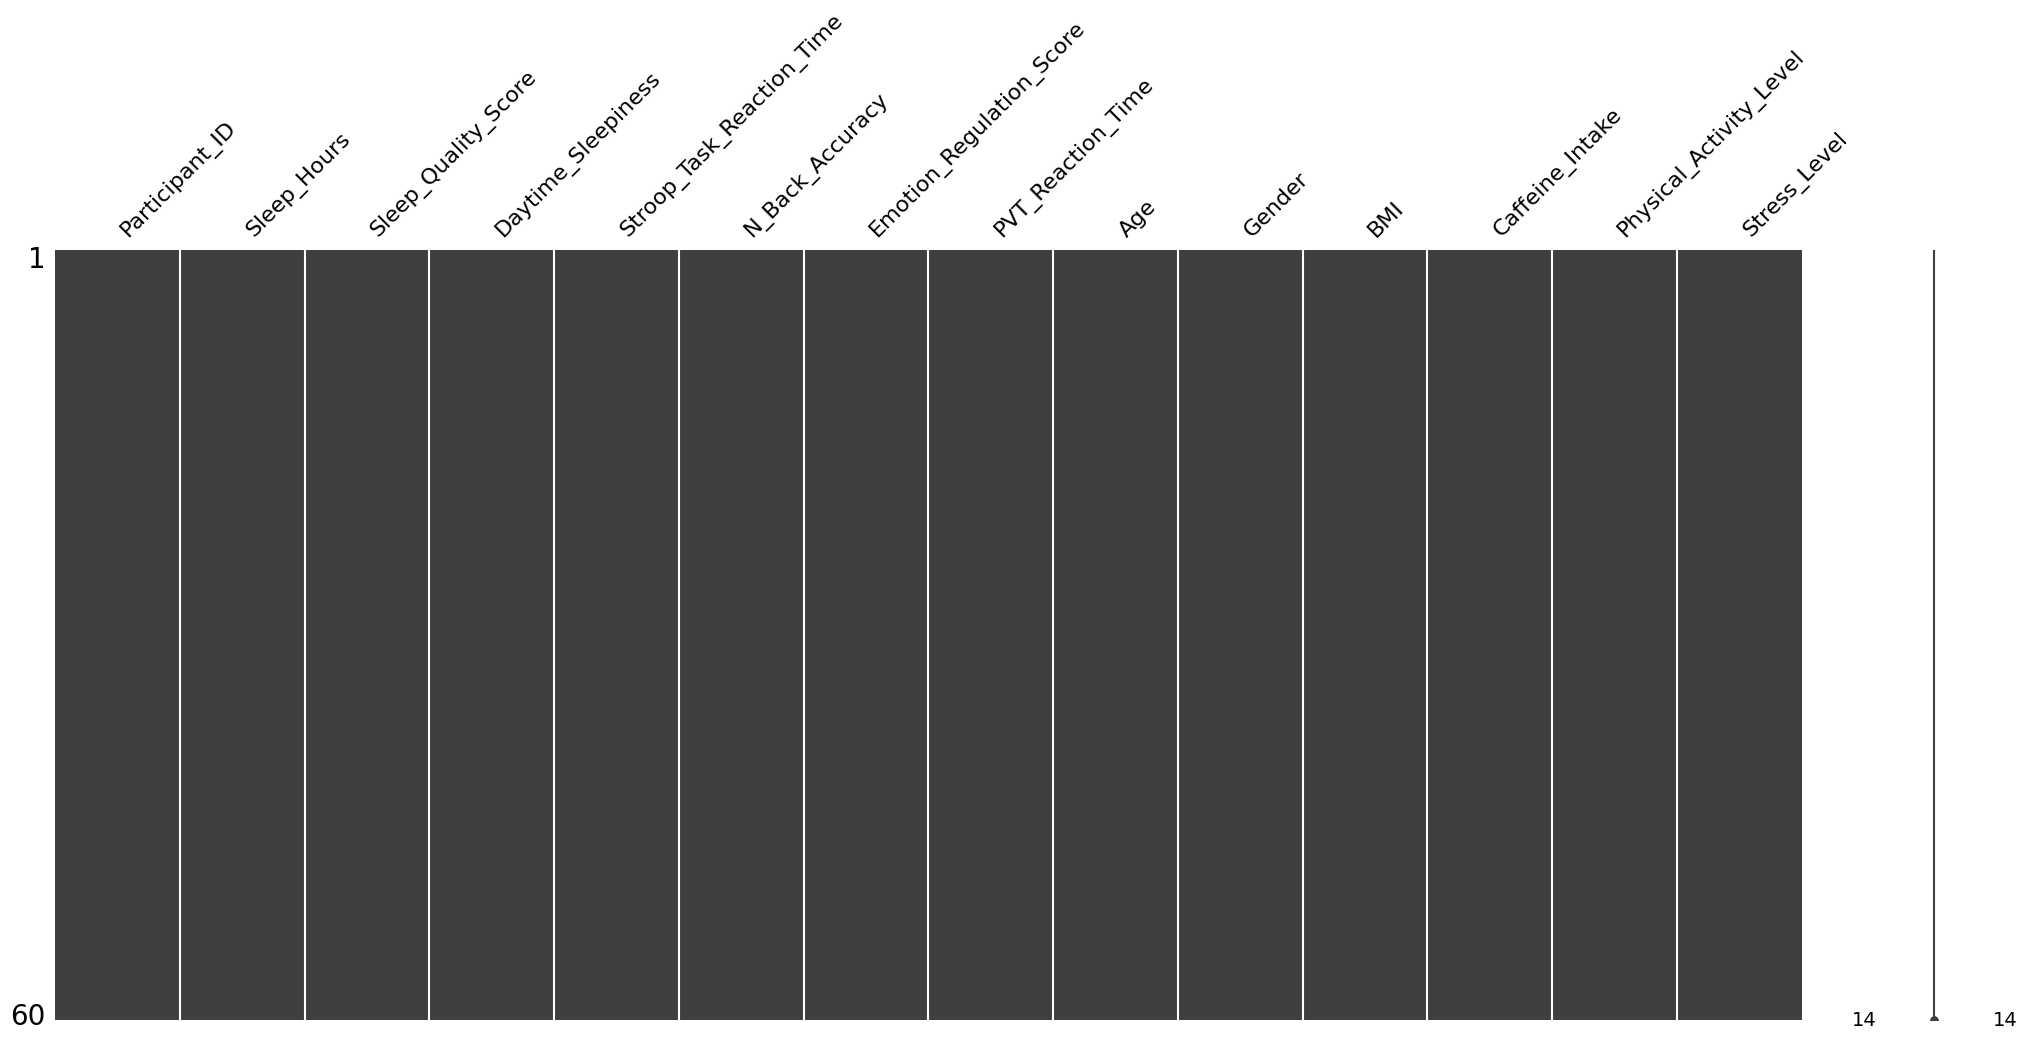

In [5]:
# Para revisar presencia de nulos
msno.matrix(df)

Como se puede ver, este dataset está completo, no presenta nulos.

### **1. Esquemas de Color**
Crea y aplica esquemas de color personalizados (monocromático, complementario, triádico, etc.) adecuados a la naturaleza de los datos.

* **Color Base**: #2baf9d

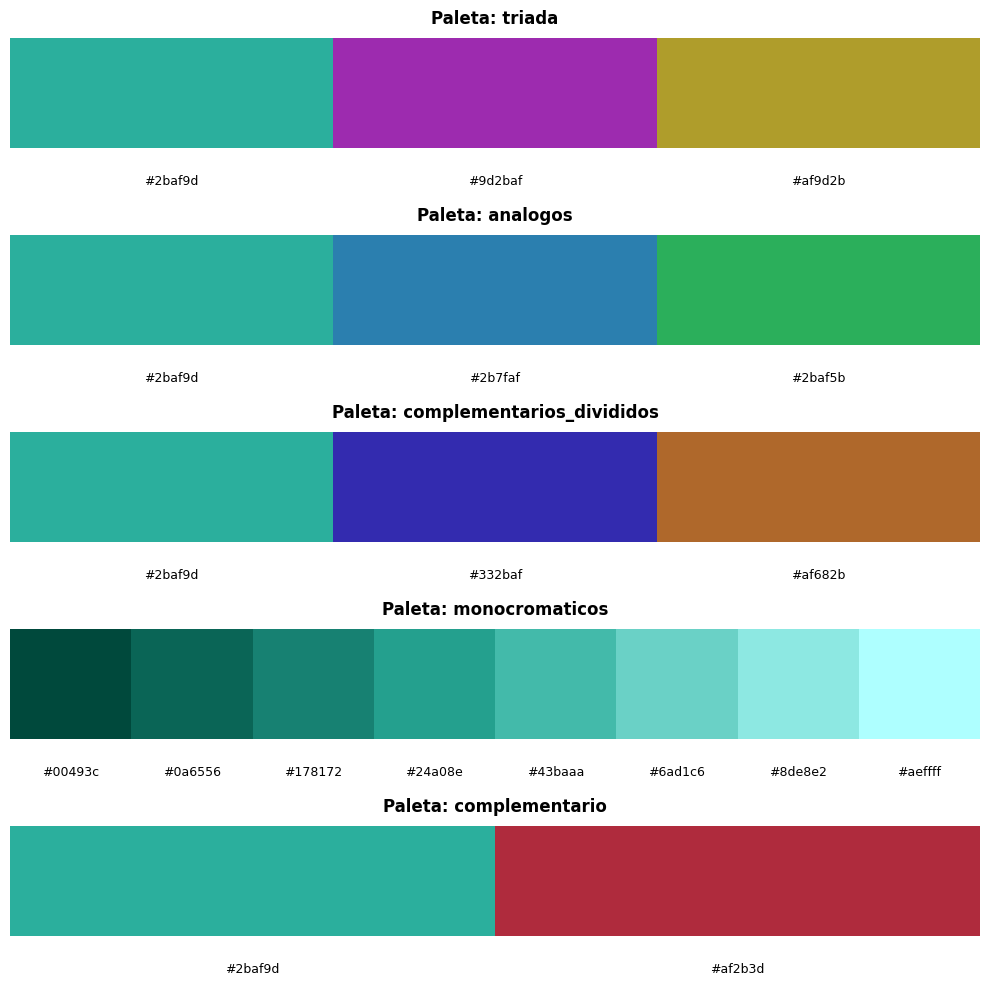

In [6]:
# 1. Definir múltiples paletas de colores en hexadecimal
triada = ['#2baf9d', '#9d2baf', '#af9d2b']
analogos = ['#2baf9d', '#2b7faf', '#2baf5b']
complementarios_divididos = ['#2baf9d', '#332baf', '#af682b']
monocromaticos = ['#00493c', '#0a6556', '#178172', '#24a08e', '#43baaa', '#6ad1c6', '#8de8e2', '#aeffff']
complementario = ['#2baf9d', '#af2b3d']

# Agrupar las paletas en un diccionario para gestión fácil
paletas = {
            'triada' : ['#2baf9d', '#9d2baf', '#af9d2b'],
            'analogos' : ['#2baf9d', '#2b7faf', '#2baf5b'],
            'complementarios_divididos' : ['#2baf9d', '#332baf', '#af682b'],
            'monocromaticos' : ['#00493c', '#0a6556', '#178172', '#24a08e', '#43baaa', '#6ad1c6', '#8de8e2', '#aeffff'],
            'complementario' : ['#2baf9d', '#af2b3d']
          }

def mostrar_paletas(paletas_dict):
    # Calcular dimensiones dinámicas basadas en la paleta más grande
    max_colores = max(len(colors) for colors in paletas_dict.values())
    num_paletas = len(paletas_dict)

    # Crear la figura y los ejes
    fig, axes = plt.subplots(num_paletas, 1, figsize=(10, 2 * num_paletas))

    # Asegurar que 'axes' sea iterable incluso si hay solo una paleta
    if num_paletas == 1:
        axes = [axes]

    # Recorrer cada paleta y su color
    for i, (nombre, colores) in enumerate(paletas_dict.items()):
        ax = axes[i]
        ax.set_xlim(0, len(colores))
        ax.set_ylim(0, 1)
        ax.axis('off')  # Ocultar ejes numéricos
        ax.set_title(f"Paleta: {nombre}", fontsize=12, fontweight='bold', pad=10)

        for j, color_hex in enumerate(colores):
            # Dibujar el rectángulo de color
            rect = patches.Rectangle((j, 0), 1, 1, linewidth=0, facecolor=color_hex)
            ax.add_patch(rect)

            # Agregar el código hexadecimal debajo del color
            ax.text(j + 0.5, -0.25, color_hex, ha='center', va='top', fontsize=9, color='black' if color_hex not in ['#F0F0F0', '#FFFFFF'] else 'black')

        # Ajustar el límite inferior para dejar espacio al texto
        ax.set_ylim(-0.4, 1)

    plt.tight_layout()
    plt.show()

# Ejecutar la función
mostrar_paletas(paletas)

### **2.Gráficos con Plotly**
Genera 10 gráficos diferentes utilizando la librería Plotly.
* Mejoras de Visualización: Agrega elementos interactivos y estéticos como rugs, asignación estratégica de color, tooltips (hover), y anotaciones.
* Contexto: Para cada gráfico, incluye un bloque de texto que explique qué se muestra y qué conclusión se puede extraer.

#### **Gráfico 1**: Nivel de Actividad Física

In [7]:
df["Activity_Group"] = pd.cut(
    df["Physical_Activity_Level"],
    bins=[-1, 3, 6, 10],
    labels=["Bajo (0–3)", "Medio (4–6)", "Alto (7–10)"]
)
activity_counts = df["Activity_Group"].value_counts().sort_index()

In [8]:
graf1 = go.Figure(data=[go.Pie(
        labels=activity_counts.index.tolist(),
        values=activity_counts.values.tolist(),
        hole=0.40,
        marker_colors=['#2baf9d', '#2b7faf', '#2baf5b'],
        textinfo="percent",
        hovertemplate="%{label}: %{value} (%{percent})<extra></extra>",
        name="Actividad"
    )])
graf1.update_layout(plot_bgcolor='#808080', paper_bgcolor='#808080', font_color='white')
graf1.update_layout(title_text="Nivel de actividad física")
graf1.show()

Conclusión: Este gráfico de dona nos muestra el grupo en el que se encuentran las personas dependiendo de su actividad física. Podemos ver que la mayoría tiene un nivel bajo-medio de actividad física. Solo el 21.7% tiene un nivel alto, lo que puede afectar la calidad del sueño.

#### **Gráfico 2**: Daytime Sleepiness por Género

In [18]:
graf2 = px.violin(df, x='Gender', y='Daytime_Sleepiness', box=True, points='all',
                  color='Gender', color_discrete_sequence=complementario,
                  title='Daytime Sleepiness por Género')

graf2.update_layout(plot_bgcolor='#808080', paper_bgcolor='#808080', font_color='white')
graf2.show()

Conclusión: con los gráficos de violín buscamos observar la distribución por género de la somnolencia (necesidad de dormir) durante el día. Podemos ver que la distribución para las mujeres, se encuentra mayormente en la parte baja, con menos tendencia a experimentar esto. Por el contrario los hombres tienden a presentar sueño en mayores valores.

#### **Gráfico 3**: Sueño, precisión cognitiva y regulación emocional

In [10]:
graf3 = px.scatter(df, x='Sleep_Hours', y='N_Back_Accuracy',
                   size='Emotion_Regulation_Score', color='BMI',
                   color_continuous_scale=monocromaticos,
                   title='Sueño, precisión cognitiva y regulación emocional')
graf3.update_layout(plot_bgcolor='#808080', paper_bgcolor='#808080', font_color='white')
graf3.show()

Conclusión: Esta gráfica muestra la relación entre horas de sueño y memoria de trabajo (N-Back). El tamaño del punto indica regulación emocional y el color el IMC de cada persona. No hay una tendencia lineal clara, lo que sugiere que la precisión cognitiva depende de múltiples factores más allá del sueño.

#### **Gráfico 4**: Daytime Sleepiness promedio por grupo de edad y género

In [11]:
bins = [18, 25, 35, 45]
labels = ['18-25', '26-35', '36-45']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False, include_lowest=True)
# 1. Agregar los datos primero
graf4_data = df.groupby(["Age_Group", "Gender"], observed=True)["Daytime_Sleepiness"].mean().round(1).reset_index()

graf4 = px.bar(
    graf4_data,
    x="Age_Group", y="Daytime_Sleepiness",
    color="Gender",
    barmode="group",
    color_discrete_sequence=complementario,
    category_orders={"Age_Group": labels, "Gender": ["Male", "Female"]},
    text="Daytime_Sleepiness",                    # 2. Mostrar el valor encima de cada barra
    labels={
        "Age_Group": "Grupo de edad",
        "Daytime_Sleepiness": "Daytime Sleepiness (promedio)",
        "Gender": "Género"
    },
    title="Daytime Sleepiness promedio por grupo de edad y género"
)

# 4. Etiquetas encima de las barras
graf4.update_traces(textposition="outside", textfont_size=12)

# 5. Escala del eje Y con margen para que no se corten las etiquetas
graf4.update_yaxes(range=[0, graf4_data["Daytime_Sleepiness"].max() * 1.25])

graf4.update_layout(plot_bgcolor='#808080', paper_bgcolor='#808080', font_color='white')
graf4.show()

Conclusión: Aquí se dividieron las edades de los registrados en grupos de 18 a 25, 26 a 35, y 36 a 45. Además, se separan por género, donde podemos ver que en dos de los grupos existen más hombres en promedio, con valores altos de presentar somnolencia durante el día. De hecho, en el grupo de 36 a 45 se puede ver una diferencia clara de más de 6 puntos, que los hombres experimentan esto más que las mujeres. Mientas que en el grupo medio de 26 a 35 años de edad, las mujeres lo presentan más, aunque la diferencia es menor a 2 puntos.

#### **Gráfico 5**: Horas de sueño vs tiempo de reacción (PVT)

In [19]:
graf5 = px.scatter(df, x='Sleep_Hours', y='PVT_Reaction_Time',
                 color='Gender',
                 size='Stress_Level', color_discrete_sequence=complementario,
                  title='Horas de sueño vs tiempo de reacción (PVT)')

graf5.update_layout(plot_bgcolor='#808080', paper_bgcolor='#808080', font_color='white')
graf5.show()

Conclusión: Este scatter plot pretende mostrar la relación entre las horas de sueño y el tiempo de reacción de cada persona, se puede ver la diferencia de género por color y el tamaño de cada punto referencia al nivel de estrés de cada persona. Se espera que entre un mayor descanso, se tendría que tener un mejor tiempo de reacción. Podemos ver que esta relación no se cumple perfectamente, pero si tenemos más valores con tiempos de reacción altos en las personas que descansaron menos. El nivel de estrés se ve más disperso, no mostrando una relación, así como el género.

#### **Gráfico 6**: Relación entre Sleep_Quality_Score & Emotion_Regulation_Score

In [25]:
graf6 = px.scatter(df, x='Sleep_Quality_Score', y='Emotion_Regulation_Score',
           color='Gender', color_discrete_sequence=complementario, # doy color a cada punto segun genero
           title='> Relación entre Sleep_Quality_Score & Emotion_Regulation_Score')
# Para el color del fondo y letras
graf6.update_layout(plot_bgcolor='#808080', paper_bgcolor='#808080', font_color='white')

# Para el tamaño de los círculos
graf6.update_traces(marker_size=15)

graf6.show()

Esta gráfica de dispersión muestra la relación entre el puntaje de la calidad del sueño (0-20) y el puntaje de la regulación emocional (10-70). El color de los círculos indica el género.

A simple vista, se puede distinguir que para la menor calidad de sueño (entre 0 y 5), los hombres son los que se posicionan con la regulación emocional más alta. Al dividir el eje de la calidad de sueño, se puede apreciar que hay una mayor concentración de participantes, tanto hombres como mujeres, entre la calidad de sueño con puntaje de 5 a 15. Mientras que en la calidad de sueño entre 15 y 20, se concentran muy pocas mujeres (3) comparadas con la cantidad de hombres (5), quienes también presentan una mejor regulación emocional en este rango de calidad de sueño.

#### **Gráfico 7**: Relación entre variables del sueño, consumo de cafeína, niveles de estrés y regulación emocional, según la edad

In [26]:
variables = ['Sleep_Hours', 'Sleep_Quality_Score',
             'Caffeine_Intake', 'Stress_Level',
             'Emotion_Regulation_Score', 'Age']

graf7 = px.parallel_coordinates(df,
                                dimensions=variables,
                                color='Age',
                                color_continuous_scale=monocromaticos,
                                labels={'Age': 'Age'},
                                title='> Relación entre variables del sueño, consumo de cafeína, niveles de estrés y regulación emocional, según la edad')

# Para el color del fondo y letras
graf7.update_layout(plot_bgcolor='#808080', paper_bgcolor='#808080', font_color='white')

graf7.show()

En esta gráfica de coordenadas paralelas, se están comparando el comportamiento de los participantes (tanto hombres como mujeres), analizando la realación entre las horas de sueño, el puntaje de la calidad de sueño, su consumo de café, nivel de estrés, puntaje de regulación emocional y como variable de 'salida', la edad de cada partipante del estudio (de 18 a 43 años).

De esta manera, lo más importante a resaltar es que quienes tuvieron más de 7 horas de sueño y una calidad de sueño mayor a 15, tienen una edad de entre 18 a 23 aproximadamente (además de un participante de 34 años).

Por otro lado, el consumo de cafeína no se comporta de una manera específica para cada rango de edad u horas de sueño, sino que todos presentan una cantidad muy variada de consumo de cafeína: los participantes que durmieron menos de 4.5 horas, presentan tanto un consumo de cafeína muy alto, como muy bajo, al igual que quienes durmieron más de 7 horas. El mismo comportamiento sucede entre la relación del consumo de cafeína y los niveles de estrés, así como la regulación emocional.

#### **Gráfico 8**: Diferencias entre los puntajes de regulación emocional de hombres y mujeres

In [27]:
graf8 = px.histogram(df, x='Emotion_Regulation_Score',
                    color='Gender', color_discrete_sequence=complementario,
                    marginal='rug',
                    facet_col='Gender',
                    title='> Diferencias entre los puntajes de regulación emocional de hombres y mujeres')

# Para el color del fondo y letras
graf8.update_layout(plot_bgcolor='#808080', paper_bgcolor='#808080', font_color='white')

graf8.show()

En estos histogramas, sólo se está comparando el comportamiento de los participantes, mujeres y hombres, con respecto a su regulación emocional (con puntajes de 0 a 70). Como se puede apreciar, las mujeres tienen una menor regulación emocional, la mayoría concentrándose entre los puntajes 30 y 40. Por el otro lado, la mayoría de los hombres se concentran entre los puntajes 20 y 30 y 60 y 70.

Estos resultados pueden ser justificados considerando el ciclo menstrual de las mujeres, donde las hormonas cambian constantemente cada 28 días, a lo largo de las 4 fases (menstruación, fase folicular, fase ovulatoria y fase lútea).

#### **Gráfico 9**: Nivel de estrés vs. Retención temporal de información

In [29]:
graf9 = px.scatter(df, x='N_Back_Accuracy', y='Stress_Level',
           hover_name='Gender', hover_data=['Age'],
           color='Stress_Level', color_continuous_scale=complementarios_divididos,
           opacity=1,
           title='> Nivel de estrés vs. Retención temporal de información')

# Para el color del fondo y letras
graf9.update_layout(plot_bgcolor='#808080', paper_bgcolor='#808080', font_color='white')

# Para el tamaño de los círculos
graf9.update_traces(marker_size=15)

graf9.show()

En esta gráfica de dispersión, se está comparando la relación entre el nivel de estrés y la retención temporal de información (N_Back_Accuracy), tanto de hombres como de mujeres.

Como se puede identificar, los participantes que tuvieron un nivel de estrés mayor o igual que 35 (puntos color café), presentan puntajes de retención de información de entre 60 y 90 (aunque hay una persona que presenta altos niveles de estrés, pero tiene una retención de información mayor a 90). Mientras los que tienen un nivel de estrés bajo-medio, de entre 0 y 30, presentan una retención de información mucho mejor, alcalzando el puntaje de casi 100.

Esto demuestra que el nivel de estrés afecta la retención de información y la memoria a corto plazo.

#### **Gráfico 10**: Calidad de Sueño de acuerdo a Consumo de Cafeína (bajo, intermedio, alto), comparación entre mujeres y hombres

In [30]:
# Para hacer rangos de la variable 'Caffeine_Category'

df['Caffeine_Category'] = df['Caffeine_Intake'].apply(lambda x: 'Bajo (<1)' if x < 2 else ('Alto (>4)' if x > 4 else 'Intermedio (2-4)'))

# Para definir el orden de las nuevas categorías
orden_categorias = {"Caffeine_Category": ['Bajo (<1)', 'Intermedio (2-4)', 'Alto (>4)']}

graf10 = px.violin(df, x='Caffeine_Category', y='Sleep_Quality_Score',
                    color='Gender', color_discrete_sequence=complementario,
                    points='all',
                    category_orders=orden_categorias,
                    title='> Calidad de Sueño de acuerdo a Consumo de Cafeína (bajo, intermedio, alto), comparación entre mujeres y hombres')

# Para el color del fondo y letras
graf10.update_layout(plot_bgcolor='#808080', paper_bgcolor='#808080', font_color='white')

# Para que la escala del eje y comience desde el 0, que es donde comienzan los datos de la variable
graf10.update_traces(spanmode='hard')

graf10.show()

En esta gráfica de violines, se muestra la comparación entre el comportamiento de mujeres y hombres, con respecto a su consumo de cafeína (bajo, intermedio y alto) y la calidad de sueño.
Como se puede ver, las mujeres que consumieron altas cantidades de cafeína durante el día (> 4), se concentraron entre la calidad de sueño de 0 a 6, mientras que los hombres entre 0 y 14.

Como contraste, quienes consumieron menores cantidades de cafeína (< 1), tanto mujeres como hombres, obtuvieron una calidad de sueño más variada, de entre 0 a 18. De la misma manera, quienes consumieron una cantidad de cafeína intermedia (2 - 4), también obtuvieron una calidad de sueño variada, de entre 0  a 20.

